# Vision Computacional — Ejercicios prácticos

Este notebook contiene ejercicios prácticos en Python (OpenCV y scikit-image) sobre **Segmentación**, **Descriptores** y **Morfología matemática**, con explicaciones y preguntas teóricas.

Instrucciones: Ejecuta las celdas en orden. Las imágenes se cargarán desde URLs.

In [18]:
# Celdas iniciales: imports y funciones auxiliares
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import local_binary_pattern
from skimage.color import rgb2gray
from skimage import morphology
from urllib.request import urlopen
import io

plt.rcParams['figure.figsize'] = (9,5)

def load_image_url(url, flags=cv2.IMREAD_COLOR):
    """Carga una imagen desde una URL y la devuelve en formato BGR (como cv2 espera) o en escala de grises."""
    resp = urlopen(url)
    data = np.asarray(bytearray(resp.read()), dtype=np.uint8)
    img = cv2.imdecode(data, flags)
    return img

def show_bgr(img, title=''):
    """Muestra imagen BGR usando matplotlib (convierte a RGB)."""
    if img is None:
        print('Imagen vacía')
        return
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) if len(img.shape)==3 else img
    plt.imshow(img_rgb, cmap='gray' if img_rgb.ndim==2 else None)
    plt.title(title); plt.axis('off')

def show_gray(img, title=''):
    plt.imshow(img, cmap='gray'); plt.title(title); plt.axis('off')


## 1) Segmentación

En esta sección verás ejemplos de segmentación por umbral, umbral adaptativo y por color (HSV). Las imágenes se cargarán desde URLs de ejemplo; puedes cambiarlas.

### 1.1 Segmentación por umbral (global y adaptativo)

**Objetivo:** separar objetos del fondo usando umbral fijo y adaptativo.


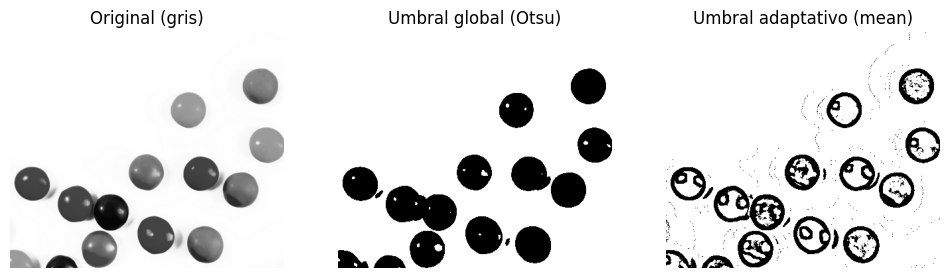

In [19]:
# Ejemplo: umbral simple y adaptativo
url = 'https://raw.githubusercontent.com/opencv/opencv/master/samples/data/smarties.png'  # ejemplo público
img = load_image_url(url, flags=cv2.IMREAD_GRAYSCALE)
if img is None:
    print('No se pudo cargar la imagen. Reemplaza la URL por otra válida.')
else:
    # umbral global (Otsu)
    _, th_global = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    # umbral adaptativo
    th_adapt = cv2.adaptiveThreshold(img, 255, cv2.ADAPTIVE_THRESH_MEAN_C,
                                     cv2.THRESH_BINARY, 11, 2)

    plt.figure(figsize=(12,4))
    plt.subplot(1,3,1); show_gray(img, 'Original (gris)')
    plt.subplot(1,3,2); show_gray(th_global, 'Umbral global (Otsu)')
    plt.subplot(1,3,3); show_gray(th_adapt, 'Umbral adaptativo (mean)')
    plt.show()


**Tareas (práctica):**

- Prueba aplicar `cv2.GaussianBlur(img, (5,5), 0)` antes de los umbrales.
- Cambia el tamaño de la ventana en el umbral adaptativo (e.g., 11 → 25) y observa los cambios.


### 1.2 Segmentación por color (espacio HSV)

Detectaremos un color (amarillo) en una imagen ejemplo.


In [20]:
# Ejemplo: segmentación por color (HSV)
url2 = 'https://upload.wikimedia.org/wikipedia/commons/4/46/Yellow_post-it_note.jpg'  # post-it amarillo
img_color = load_image_url(url2, flags=cv2.IMREAD_COLOR)
if img_color is None:
    print('No se pudo cargar la imagen. Reemplaza la URL por otra válida.')
else:
    hsv = cv2.cvtColor(img_color, cv2.COLOR_BGR2HSV)
    # rango para amarillo (ajustable)
    low = np.array([20, 100, 100])
    high = np.array([40, 255, 255])
    mask = cv2.inRange(hsv, low, high)
    res = cv2.bitwise_and(img_color, img_color, mask=mask)

    plt.figure(figsize=(12,4))
    plt.subplot(1,3,1); show_bgr(img_color, 'Original')
    plt.subplot(1,3,2); show_gray(mask, 'Máscara (HSV)')
    plt.subplot(1,3,3); show_bgr(res, 'Resultado (aplicada máscara)')
    plt.show()


HTTPError: HTTP Error 403: Forbidden

**Tareas (práctica):**

- Ajusta los límites `low` y `high` para detectar otros colores (rojo/azul).
- Combina máscaras para detectar objetos multicolor.


## 2) Descriptores

Extraeremos propiedades geométricas (momentos de Hu, área, perímetro) y descriptores de textura (LBP).


### 2.1 Momentos de Hu y propiedades de contorno

Calcularemos área, perímetro y los 7 momentos invariantes de Hu para cada contorno.


In [21]:
# Ejemplo: momentos de Hu y propiedades de contorno
url3 = 'https://raw.githubusercontent.com/opencv/opencv/master/samples/data/coins.jpg'
img3_color = load_image_url(url3, flags=cv2.IMREAD_COLOR)
img3_gray = cv2.cvtColor(img3_color, cv2.COLOR_BGR2GRAY)
_, img3_bin = cv2.threshold(img3_gray, 120, 255, cv2.THRESH_BINARY_INV+cv2.THRESH_OTSU)

contours, _ = cv2.findContours(img3_bin, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

out = img3_color.copy()
for i, c in enumerate(contours):
    area = cv2.contourArea(c)
    per = cv2.arcLength(c, True)
    hu = cv2.HuMoments(cv2.moments(c)).flatten()
    # dibujar contorno y centroide
    M = cv2.moments(c)
    if M['m00']!=0:
        cx = int(M['m10']/M['m00']); cy = int(M['m01']/M['m00'])
        cv2.putText(out, f'{i}', (cx-10, cy), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,0,255), 2)
    cv2.drawContours(out, [c], -1, (0,255,0), 2)
    print(f'Contorno {i}: área={area:.1f}, perímetro={per:.1f}, Hu[0]={hu[0]:.3e}')

plt.figure(figsize=(10,6)); show_bgr(out, 'Contornos numerados')
plt.show()


HTTPError: HTTP Error 404: Not Found

**Tareas (práctica):**

- Filtra contornos por área (por ejemplo, `area > 500`).
- Normaliza/transforma los momentos de Hu (log escala) y compara entre objetos.


### 2.2 Descriptor de textura: LBP (Local Binary Patterns)

Calcularemos el mapa LBP y su histograma como descriptor.


In [22]:
# Ejemplo: LBP
url4 = 'https://upload.wikimedia.org/wikipedia/commons/6/65/Wood_texture.jpg'
img4 = load_image_url(url4, flags=cv2.IMREAD_GRAYSCALE)
if img4 is None:
    print('No se pudo cargar la imagen. Cambia la URL.')
else:
    lbp = local_binary_pattern(img4, P=8, R=1, method='uniform')
    # histograma (normalizado)
    n_bins = int(lbp.max() + 1)
    hist, _ = np.histogram(lbp.ravel(), bins=n_bins, range=(0, n_bins), density=True)

    plt.subplot(1,2,1); show_gray(img4, 'Textura (gris)')
    plt.subplot(1,2,2); show_gray(lbp, 'LBP')
    plt.show()
    print('Histograma LBP (primeros 10 valores):', hist[:10])


HTTPError: HTTP Error 403: Forbidden

**Tareas (práctica):**

- Usa el histograma LBP como vector descriptor y compara dos imágenes (distancia euclidiana o coseno).
- Experimenta con diferentes `P` y `R` en LBP.


## 3) Morfología matemática

Operaciones básicas y una práctica de granulometría.


### 3.1 Erosión, dilatación, apertura y cierre

Aplicaremos operaciones morfológicas sobre una imagen binaria con ruido.


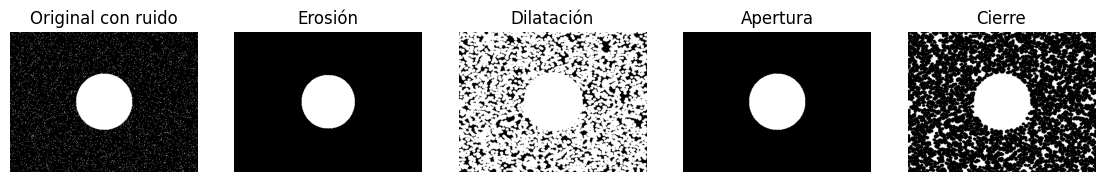

In [23]:
# Ejemplo: operaciones morfológicas
h, w = 300, 400
np.random.seed(0)
img_noise = (np.random.rand(h,w) > 0.96).astype('uint8') * 255
# añadimos un objeto grande
cv2.circle(img_noise, (200,150), 60, 255, -1)

kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7,7))
erosion = cv2.erode(img_noise, kernel, iterations=1)
dilat = cv2.dilate(img_noise, kernel, iterations=1)
apertura = cv2.morphologyEx(img_noise, cv2.MORPH_OPEN, kernel)
cierre = cv2.morphologyEx(img_noise, cv2.MORPH_CLOSE, kernel)

plt.figure(figsize=(14,4))
plt.subplot(1,5,1); show_gray(img_noise, 'Original con ruido')
plt.subplot(1,5,2); show_gray(erosion, 'Erosión')
plt.subplot(1,5,3); show_gray(dilat, 'Dilatación')
plt.subplot(1,5,4); show_gray(apertura, 'Apertura')
plt.subplot(1,5,5); show_gray(cierre, 'Cierre')
plt.show()


**Tareas (práctica):**

- Cambia el tamaño y la forma del elemento estructurante (`cv2.getStructuringElement`) y observa efectos.


### 3.2 Granulometría morfológica

Estimaremos el cambio de área blanca restante al aplicar aperturas con elementos crecientes.


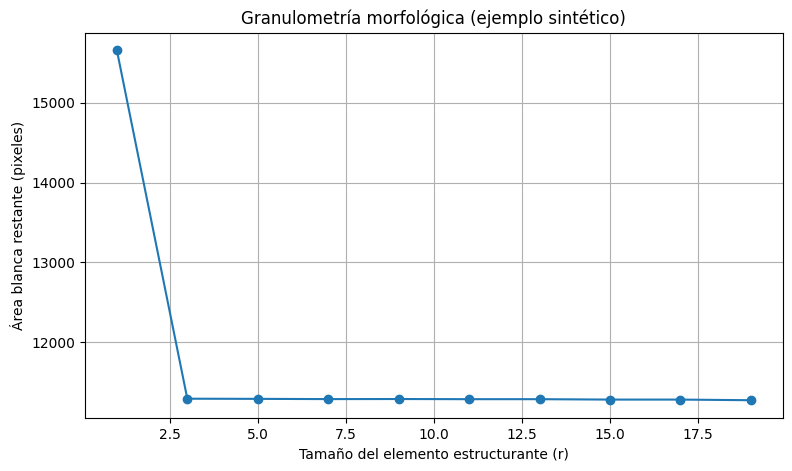

In [16]:
# Ejemplo: granulometría morfológica
areas = []
radii = list(range(1, 20, 2))
for r in radii:
    k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (r, r))
    opened = cv2.morphologyEx(img_noise, cv2.MORPH_OPEN, k)
    area = np.sum(opened == 255)
    areas.append(area)

plt.plot(radii, areas, marker='o')
plt.xlabel('Tamaño del elemento estructurante (r)')
plt.ylabel('Área blanca restante (pixeles)')
plt.title('Granulometría morfológica (ejemplo sintético)')
plt.grid(True)
plt.show()


**Tareas (práctica):**

- Interpreta la gráfica: picos y caídas ¿qué indican sobre la distribución de tamaños de partículas?
- Implementa la versión que calcula la derivada discreta del vector `areas` para estimar la 'densidad de tamaños'.


## 4) Preguntas teóricas (para evaluar)

Responde brevemente — 4 preguntas por tema.

### Segmentación
1. ¿Cuál es la diferencia entre umbral global y umbral adaptativo? ¿Cuándo usarías cada uno?
2. ¿Qué ventajas aporta segmentar en HSV vs RGB?
3. Menciona dos limitaciones comunes de la segmentación por color.
4. ¿Qué es Otsu y para qué sirve?

### Descriptores
1. ¿Qué propiedades invariantes capturan los momentos de Hu?
2. ¿Por qué normalizamos histogramas de LBP antes de compararlos?
3. Da un ejemplo de cuándo usarías un descriptor global vs local.
4. ¿Qué es la relación entre perímetro y área para distinguir formas (ejemplo: círculo vs figura alargada)?

### Morfología matemática
1. Describe en una frase la diferencia entre apertura y cierre.
2. ¿Qué efecto tiene un elemento estructurante grande vs pequeño?
3. ¿Para qué sirve la granulometría morfológica?
4. ¿Qué operación usarías para rellenar pequeños huecos dentro de un objeto binario?


## 5) Ejercicios propuestos (mini-laboratorio)

1. Crea una función que reciba una imagen RGB y devuelva las coordenadas de los post-its amarillos detectados (bounding boxes).
2. Implementa un clasificador simple que use histograma LBP para distinguir entre dos texturas (por ejemplo, madera vs tela). Usa k-NN.
3. Realiza una granulometría sobre una imagen real de partículas (elige una URL) y interpreta los resultados.

Si quieres, puedo generar también una versión extendida con más ejercicios (evaluación automática) o preparar las soluciones en celdas separadas.
